# 🔥 FireVision : Détection d'Incendies (Dataset D-Fire)
Pipeline complet : de l'exploration des données à l'entraînement du modèle YOLO.

In [1]:
# Installation de la bibliothèque YOLO
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00


In [2]:
# Importation de tous les outils nécessaires
import os
import glob
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from tqdm.notebook import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Configuration des chemins
Recherche automatique du dataset sur Kaggle pour éviter les erreurs de dossier.

In [3]:
# On cherche où Kaggle a rangé le dataset D-Fire
DATASET_PATH = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'val' in dirs:
        DATASET_PATH = root
        break

TRAIN_IMG = os.path.join(DATASET_PATH, 'train', 'images')
TRAIN_LBL = os.path.join(DATASET_PATH, 'train', 'labels')

print(f"Dossier racine trouvé : {DATASET_PATH}")

Dossier racine trouvé : /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data


## 2. Exploration des données (EDA)
Vérification de la qualité des images. Un modèle ne peut pas apprendre sur des fichiers corrompus.

In [4]:
# Liste de toutes les images d'entraînement
images_list = glob.glob(os.path.join(TRAIN_IMG, "*.*"))
print(f"Nombre total d'images trouvées : {len(images_list)}")

Nombre total d'images trouvées : 14122


In [5]:
# Vérification des images corrompues sur l'intégralité du dataset
images_corrompues = 0

for img_path in tqdm(images_list, desc="Scan de toutes les images"):
    img = cv2.imread(img_path)
    if img is None:
        images_corrompues += 1

print(f"Images corrompues détectées : {images_corrompues}")

Scan de toutes les images:   0%|          | 0/14122 [00:00<?, ?it/s]

Images corrompues détectées : 0


## 3. Analyse des Annotations
Comptage du nombre de flammes et de fumées pour vérifier l'équilibre du dataset.

In [6]:
# Lecture des fichiers textes (labels)
labels_list = glob.glob(os.path.join(TRAIN_LBL, "*.txt"))

count_smoke = 0
count_fire = 0
empty_backgrounds = 0

for lbl_path in tqdm(labels_list, desc="Analyse des labels"):
    with open(lbl_path, 'r') as f:
        lignes = f.readlines()
        if len(lignes) == 0:
            empty_backgrounds += 1
            
        for ligne in lignes:
            classe = int(ligne.split()[0])
            if classe == 0:
                count_smoke += 1
            elif classe == 1:
                count_fire += 1

Analyse des labels:   0%|          | 0/14122 [00:00<?, ?it/s]

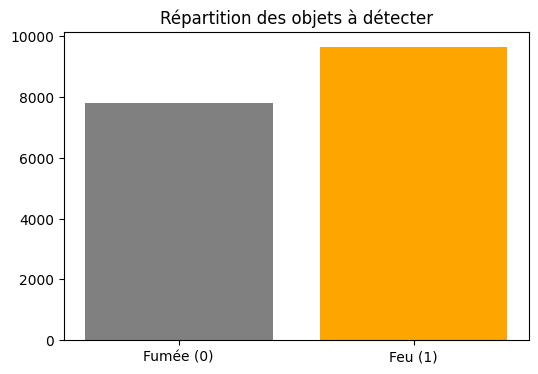

Images vides (Background) : 6458


In [7]:
# Affichage du graphique
plt.figure(figsize=(6, 4))
plt.bar(['Fumée (0)', 'Feu (1)'], [count_smoke, count_fire], color=['gray', 'orange'])
plt.title("Répartition des objets à détecter")
plt.show()

print(f"Images vides (Background) : {empty_backgrounds}")

## 4. Visualisation (Test des contours)
Vérification visuelle que les annotations YOLO encadrent bien le feu sur l'image.

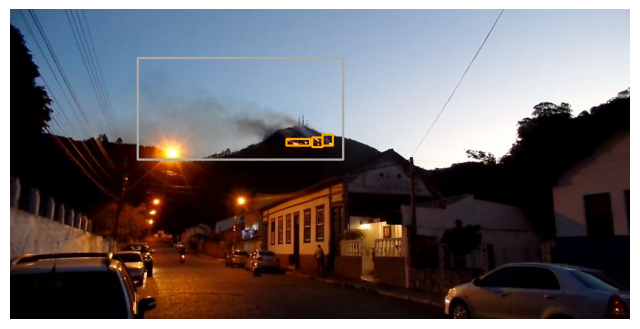

In [8]:
# 1. On définit la recette de la fonction avec la variable générique "nom_image"
def voir_image_annotee(nom_image):
    img_path = os.path.join(TRAIN_IMG, nom_image + '.jpg')
    lbl_path = os.path.join(TRAIN_LBL, nom_image + '.txt')
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    with open(lbl_path, 'r') as f:
        for ligne in f.readlines():
            classe, x, y, width, height = map(float, ligne.split())
            x1, y1 = int((x - width/2) * w), int((y - height/2) * h)
            x2, y2 = int((x + width/2) * w), int((y + height/2) * h)
            
            couleur = (255, 165, 0) if int(classe) == 1 else (169, 169, 169)
            cv2.rectangle(img, (x1, y1), (x2, y2), couleur, 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

voir_image_annotee('WEB07446')

## 5. Entraînement du Modèle
Lancement de YOLOv26s sur le GPU T4 x2.

In [9]:
# Chargement du modèle
model = YOLO('yolo26s.pt')

In [10]:
import yaml

# 1. On crée un fichier YAML parfait dynamiquement
configuration_data = {
    'path': DATASET_PATH,
    'train': 'train/images', 
    'val': 'val/images',
    'test': 'test/images',
    'names': {0: 'smoke', 1: 'fire'}
}

# On sauvegarde ce fichier dans l'espace de travail Kaggle
fichier_yaml = '/kaggle/working/custom_data.yaml'
with open(fichier_yaml, 'w') as f:
    yaml.dump(configuration_data, f)

print(f" Fichier de configuration créé avec succès : {fichier_yaml}")

# 2. On lance l'entraînement en utilisant ce nouveau fichier
results = model.train(
    data=fichier_yaml,  # On donne le chemin du fichier fraîchement créé
    epochs=50,
    patience=10,
    imgsz=640,
    batch=32, 
    project='/kaggle/working/FireVision',
    name='fire_model_final'
)

 Fichier de configuration créé avec succès : /kaggle/working/custom_data.yaml
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/custom_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_model_final, nbs=64, nms=Fal

## 6. Récupération des résultats
Affichage de la matrice et localisation du fichier final `best.pt` à télécharger.

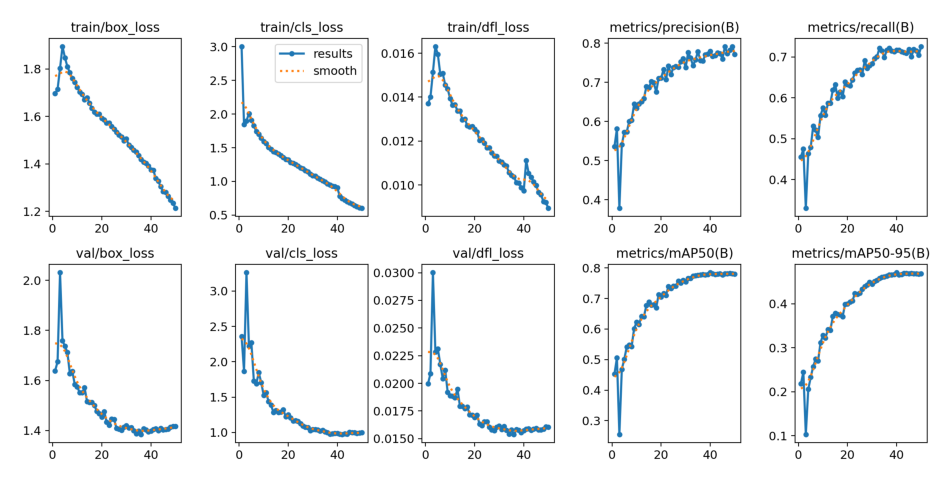

Chemin du modèle à télécharger : /kaggle/working/FireVision/fire_model_final/weights/best.pt


In [11]:
# Chemin mis à jour avec "fire_model_final"
result_img_path = '/kaggle/working/FireVision/fire_model_final/results.png' 

if os.path.exists(result_img_path):
    img_res = mpimg.imread(result_img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_res)
    plt.axis('off')
    plt.show()

print("Chemin du modèle à télécharger : /kaggle/working/FireVision/fire_model_final/weights/best.pt")